In [115]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
import mplhep as hep 
import uproot
from scipy.stats import bootstrap
import re
import sys
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, fcluster
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm  # For PDF and initial guesses
from scipy import stats
plt.style.use(hep.style.CMS)

In [116]:
file = uproot.open("Square_LYSO.root")

ps_tree = file["TruthPs"]


In [117]:
raw=ps_tree.arrays(["PosX_mm", "PosY_mm", "PosZ_mm"], library="pd")
raw.describe()

,PosX_mm,PosY_mm,PosZ_mm
count,22544.000000,22544.000000,22544.000000
mean,0.038250,-0.041851,0.017805
std,4.078967,4.181615,1.818917
min,-102.561129,-109.606669,-71.856411
25%,-1.912106,-1.961972,-0.342356
50%,0.025737,-0.008940,0.000195
75%,1.986513,1.966047,0.349088
max,103.708807,102.934032,62.086241


(-10.0, 10.0)

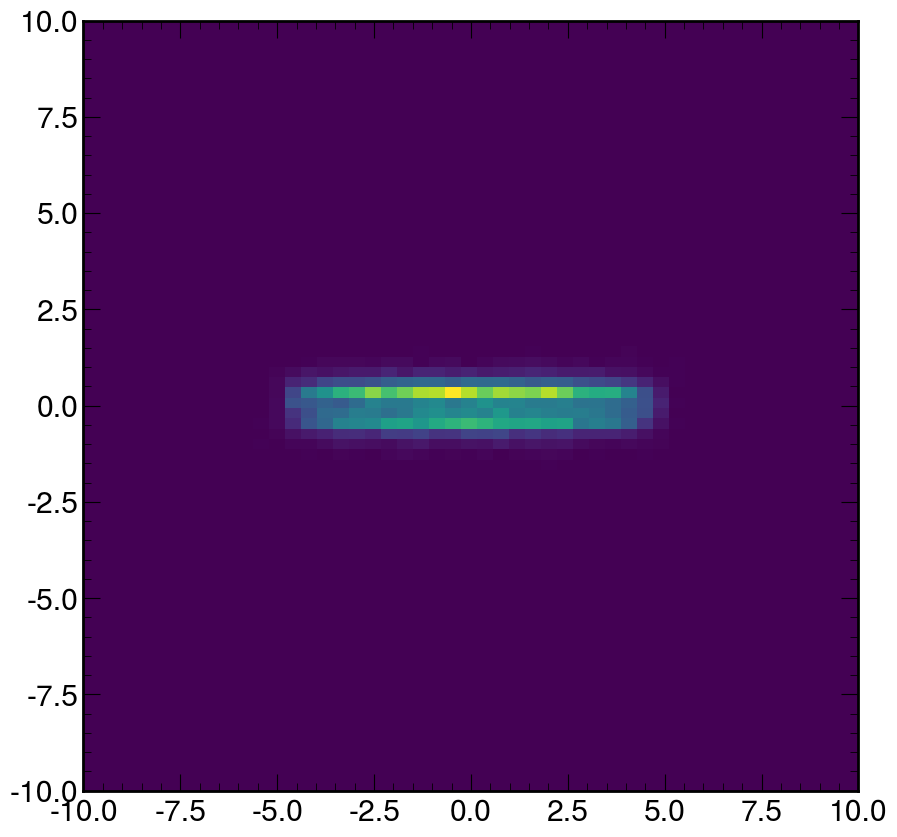

In [118]:
plt.hist2d(raw["PosX_mm"],raw["PosZ_mm"],bins=500)
plt.xlim(-10,10)
plt.ylim(-10,10)

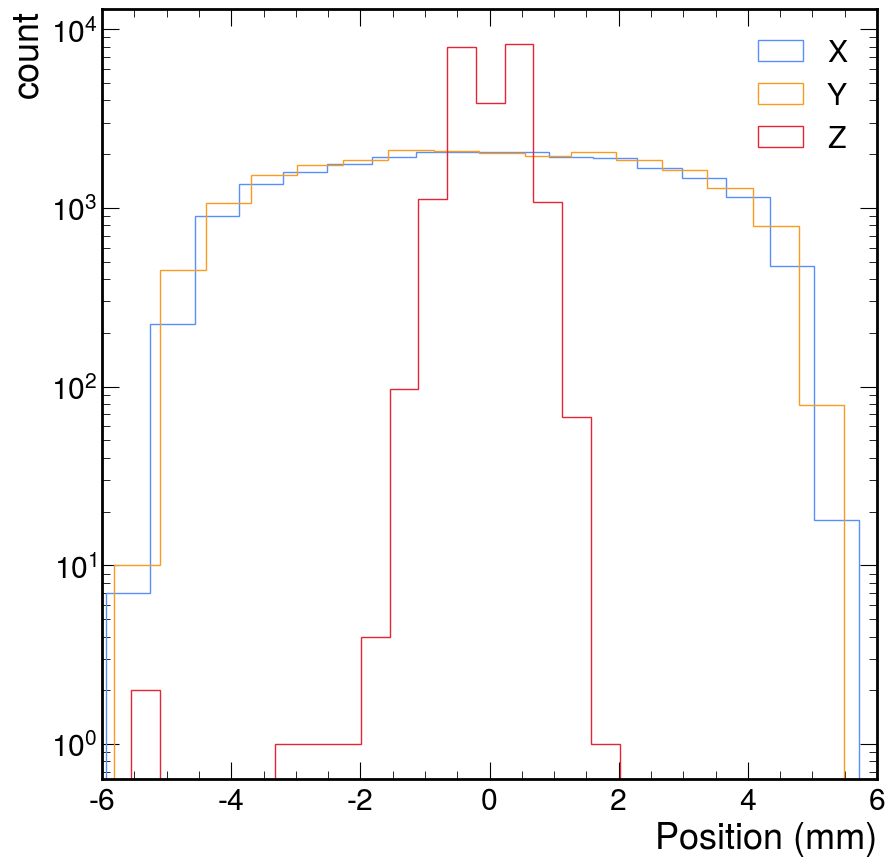

In [ ]:
plt.hist(raw["PosX_mm"],bins="auto",label="X",histtype="step",log=True)
plt.hist(raw["PosY_mm"],bins="auto",label="Y",histtype="step",log=True)
plt.hist(raw["PosZ_mm"],bins="auto",label="Z",histtype="step",log=True)
plt.xlabel("Position (mm)")
plt.ylabel("count")
plt.xlim(-6,6)
plt.legend()

(array([1.510e+02, 4.550e+02, 6.970e+02, 1.021e+03, 1.237e+03, 1.522e+03,
        1.842e+03, 2.118e+03, 2.446e+03, 2.581e+03, 2.813e+03, 2.769e+03,
        2.526e+03, 2.830e+02, 3.000e+01, 4.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

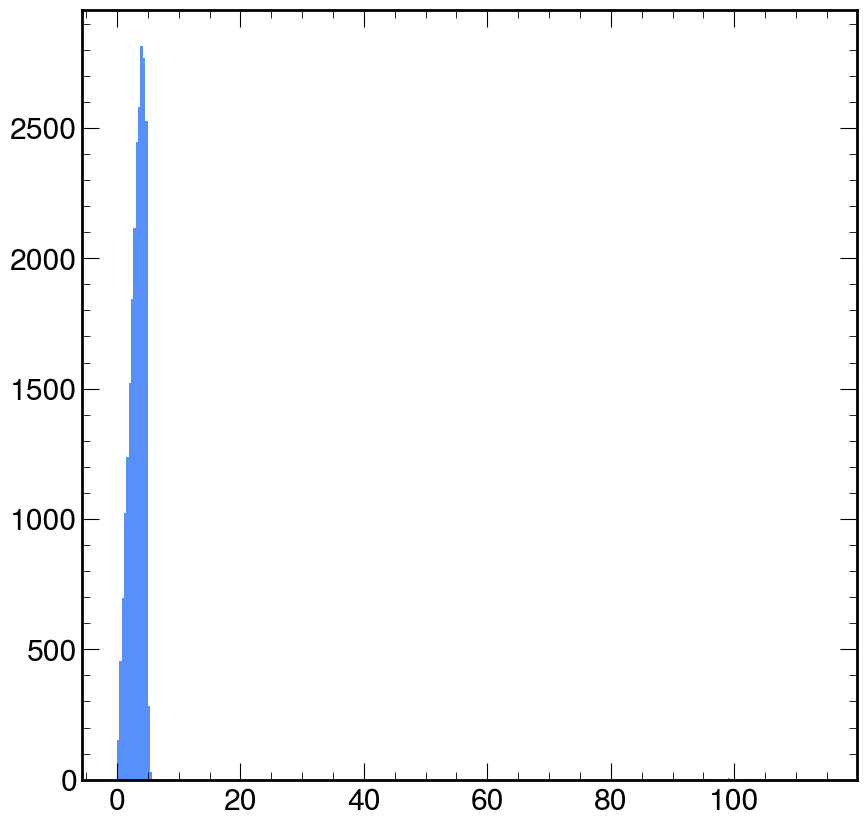

In [120]:
plt.hist(np.sqrt((raw["PosX_mm"]**2+raw["PosY_mm"]**2)),bins="auto")

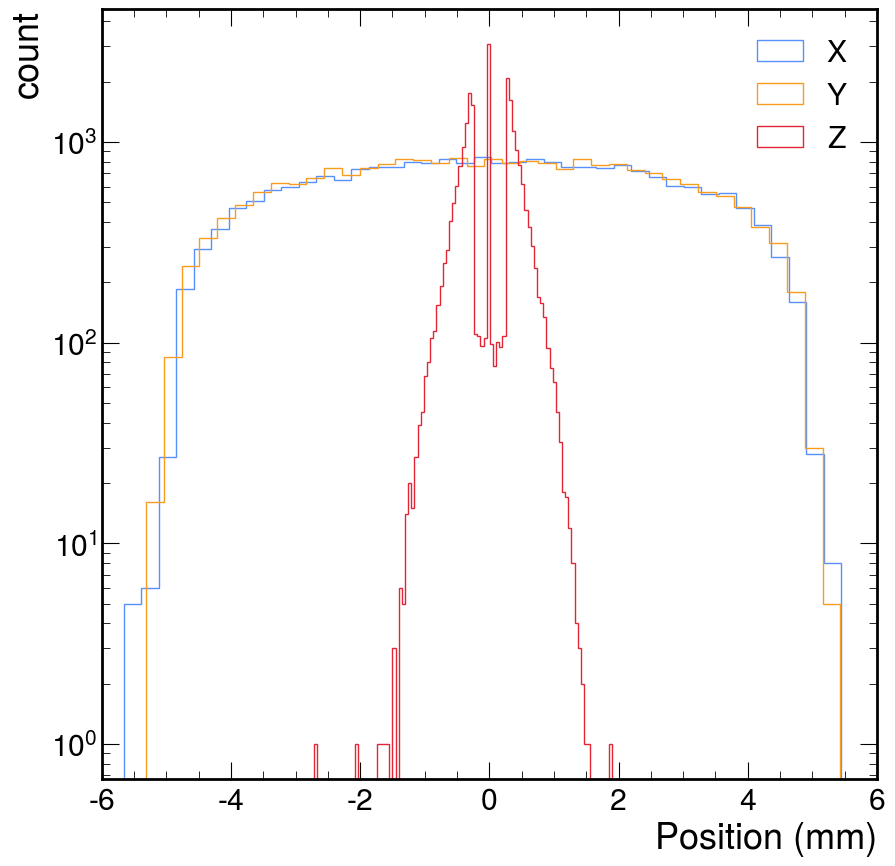

In [130]:
filter=raw[(raw["PosX_mm"]>-6) & (raw["PosX_mm"]<6)]
filter=filter[(filter["PosY_mm"]>-6) & (filter["PosY_mm"]<6)]
filter=filter[(filter["PosZ_mm"]>-6) & (filter["PosZ_mm"]<6)]
plt.hist(filter["PosX_mm"],bins="auto",label="X",histtype="step",log=True)
plt.hist(filter["PosY_mm"],bins="auto",label="Y",histtype="step",log=True)
plt.hist(filter["PosZ_mm"],bins="auto",label="Z",histtype="step",log=True)
plt.xlabel("Position (mm)")
plt.ylabel("count")
plt.xlim(-6,6)
plt.legend()
df=filter

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Updated function with quantile clipping
def create_hist_file(data, filename, bins='auto', quantile_low=0.00, quantile_high=1.00, epsilon_factor=0.00, plot=False):
    if len(data) == 0:
        print(f"No data for {filename}. Skipping.")
        return None, None
    # Clip to quantiles to ignore outliers
    q_low, q_high = np.quantile(data, [quantile_low, quantile_high])
    clipped_data = data[(data >= q_low) & (data <= q_high)]
    if len(clipped_data) == 0:
        q_low, q_high = data.min(), data.max()
        clipped_data = data
    min_val, max_val = q_low, q_high
    bin_edges = np.histogram_bin_edges(clipped_data, bins=bins)
    counts, _ = np.histogram(clipped_data, bins=bin_edges)
    bin_widths = np.diff(bin_edges)
    densities = counts / (bin_widths * counts.sum() + 1e-10)
    # Adaptive epsilon: small relative to peak, but ensures min >0
    epsilon = epsilon_factor * densities.max() if densities.max() > 0 else 1e-5
    densities += epsilon
    # Renormalize to approximate PDF
    densities /= densities.sum() * bin_widths.mean()
    with open(filename, 'w') as f:
        for upper_edge, density in zip(bin_edges[1:], densities):
            f.write(f"{upper_edge} {density}\n")
    print(f"Created {filename} with {len(bin_edges)-1} bins. Clipped range: {min_val:.3f} to {max_val:.3f}")
    print(f"Density variation: max={densities.max():.3e}, min={densities.min():.3e} (ratio={densities.max()/densities.min() if densities.min() > 0 else 'inf'})")
    
    if plot:
        plt.stairs(densities, bin_edges, fill=True)
        plt.title(f"Histogram for {filename}")
        plt.xlabel("Position (mm)")
        plt.ylabel("Density")
        plt.savefig(f"{filename}.png")
        plt.close()
    
    return min_val, max_val

# Generate histograms and get clipped mins/maxes
x_min, x_max = create_hist_file(df['PosX_mm'], 'biasx.dat', plot=True)
y_min, y_max = create_hist_file(df['PosY_mm'], 'biasy.dat', plot=True)
z_min, z_max = create_hist_file(df['PosZ_mm'], 'biasz.dat', plot=True)

# Compute bounds based on clipped ranges (with small padding)
pad = 0.0  # 10% on clipped range
if x_min is not None:
    halfx = (x_max - x_min) / 2 * (1 + pad)
    centre_x = (x_min + x_max) / 2
    print(f"Suggested halfx={halfx:.3f} mm, centre_x={centre_x:.3f} mm")
if y_min is not None:
    halfy = (y_max - y_min) / 2 * (1 + pad)
    centre_y = (y_min + y_max) / 2
    print(f"Suggested halfy={halfy:.3f} mm, centre_y={centre_y:.3f} mm")
if z_min is not None:
    halfz = (z_max - z_min) / 2 * (1 + pad)
    centre_z = (z_min + z_max) / 2
    print(f"Suggested halfz={halfz:.3f} mm, centre_z={centre_z:.3f} mm")

Created biasx.dat with 41 bins. Clipped range: -5.658 to 5.449
Density variation: max=1.378e-01, min=8.204e-04 (ratio=168.0)
Created biasy.dat with 39 bins. Clipped range: -5.315 to 5.436
Density variation: max=1.348e-01, min=8.063e-04 (ratio=167.20000000000107)
Created biasz.dat with 95 bins. Clipped range: -2.716 to 1.904
Density variation: max=2.813e+00, min=0.000e+00 (ratio=inf)
Suggested halfx=5.554 mm, centre_x=-0.104 mm
Suggested halfy=5.376 mm, centre_y=0.060 mm
Suggested halfz=2.310 mm, centre_z=-0.406 mm


In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


# Updated function with quantile clipping
def create_hist_file(data, filename, bins='auto', quantile_low=0.00, quantile_high=1.00, epsilon_factor=0.00, plot=False):
    if len(data) == 0:
        print(f"No data for {filename}. Skipping.")
        return None, None
    # Clip to quantiles to ignore outliers
    q_low, q_high = np.quantile(data, [quantile_low, quantile_high])
    clipped_data = data[(data >= q_low) & (data <= q_high)]
    if len(clipped_data) == 0:
        q_low, q_high = data.min(), data.max()
        clipped_data = data
    min_val, max_val = q_low, q_high
    bin_edges = np.histogram_bin_edges(clipped_data, bins=bins)
    counts, _ = np.histogram(clipped_data, bins=bin_edges)
    bin_widths = np.diff(bin_edges)
    densities = counts / (bin_widths * counts.sum() + 1e-10)
    # Adaptive epsilon: small relative to peak, but ensures min >0
    epsilon = epsilon_factor * densities.max() if densities.max() > 0 else 1e-5
    densities += epsilon
    # Renormalize to approximate PDF
    densities /= densities.sum() * bin_widths.mean()
    with open(filename, 'w') as f:
        for upper_edge, density in zip(bin_edges[1:], densities):
            f.write(f"{upper_edge} {density}\n")
    print(f"Created {filename} with {len(bin_edges)-1} bins. Clipped range: {min_val:.3f} to {max_val:.3f}")
    print(f"Density variation: max={densities.max():.3e}, min={densities.min():.3e} (ratio={densities.max()/densities.min() if densities.min() > 0 else 'inf'})")
    
    if plot:
        plt.stairs(densities, bin_edges, fill=True)
        plt.title(f"Histogram for {filename}")
        plt.xlabel("Position (mm)")
        plt.ylabel("Density")
        plt.savefig(f"{filename}.png")
        plt.close()
    
    return min_val, max_val
#r = np.sqrt(df['PosX_mm']**2 + df['PosY_mm']**2)
phi = np.arctan2(df['PosY_mm'], df['PosX_mm'])
phi[phi < 0] += 2 * np.pi  # 0 to 2pi

# Generate histograms
r_min, r_max = create_hist_file(r, 'biaspt.dat', plot=True)
phi_min, phi_max = create_hist_file(phi, 'biaspp.dat', plot=True)  # Likely flat; check ratio
z_min, z_max = create_hist_file(df['PosZ_mm'], 'biasz.dat', plot=True)

# Bounds (padded; r_max for radius, halfz from z)
pad = 0.1
if r_min is not None:
    radius = r_max * (1 + pad)
    print(f"Suggested radius={radius:.3f} mm")
if z_min is not None:
    halfz = (z_max - z_min) / 2 * (1 + pad)
    centre_z = (z_min + z_max) / 2
    print(f"Suggested halfz={halfz:.3f} mm, centre_z={centre_z:.3f} mm")

Created biaspt.dat with 301 bins. Clipped range: 0.025 to 114.149
Density variation: max=3.291e-01, min=0.000e+00 (ratio=inf)
Created biaspp.dat with 29 bins. Clipped range: 0.000 to 6.283
Density variation: max=1.687e-01, min=1.483e-01 (ratio=1.1369294605809128)
Created biasz.dat with 95 bins. Clipped range: -2.716 to 1.904
Density variation: max=2.813e+00, min=0.000e+00 (ratio=inf)
Suggested radius=125.564 mm
Suggested halfz=2.541 mm, centre_z=-0.406 mm


In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


# Updated function with quantile clipping
def create_hist_file(data, filename, bins='auto', quantile_low=0.00, quantile_high=1.00, epsilon_factor=0.00, plot=False):
    if len(data) == 0:
        print(f"No data for {filename}. Skipping.")
        return None, None
    # Clip to quantiles to ignore outliers
    q_low, q_high = np.quantile(data, [quantile_low, quantile_high])
    clipped_data = data[(data >= q_low) & (data <= q_high)]
    if len(clipped_data) == 0:
        q_low, q_high = data.min(), data.max()
        clipped_data = data
    min_val, max_val = q_low, q_high
    bin_edges = np.histogram_bin_edges(clipped_data, bins=bins)
    counts, _ = np.histogram(clipped_data, bins=bin_edges)
    bin_widths = np.diff(bin_edges)
    densities = counts / (bin_widths * counts.sum() + 1e-10)
    # Adaptive epsilon: small relative to peak, but ensures min >0
    epsilon = epsilon_factor * densities.max() if densities.max() > 0 else 1e-5
    densities += epsilon
    # Renormalize to approximate PDF
    densities /= densities.sum() * bin_widths.mean()
    with open(filename, 'w') as f:
        for upper_edge, density in zip(bin_edges[1:], densities):
            f.write(f"{upper_edge} {density}\n")
    print(f"Created {filename} with {len(bin_edges)-1} bins. Clipped range: {min_val:.3f} to {max_val:.3f}")
    print(f"Density variation: max={densities.max():.3e}, min={densities.min():.3e} (ratio={densities.max()/densities.min() if densities.min() > 0 else 'inf'})")
    
    if plot:
        plt.stairs(densities, bin_edges, fill=True)
        plt.title(f"Histogram for {filename}")
        plt.xlabel("Position (mm)")
        plt.ylabel("Density")
        plt.savefig(f"{filename}.png")
        plt.close()
    
    return min_val, max_val
#r = np.sqrt(df['PosX_mm']**2 + df['PosY_mm']**2)
phi = np.arctan2(df['PosY_mm'], df['PosX_mm'])
phi[phi < 0] += 2 * np.pi  # 0 to 2pi

# Generate histograms
r_min, r_max = create_hist_file(r, 'biaspt.dat', plot=True)
phi_min, phi_max = create_hist_file(phi, 'biaspp.dat', plot=True)  # Likely flat; check ratio
z_min, z_max = create_hist_file(df['PosZ_mm'], 'biasz.dat', plot=True)

# Bounds (padded; r_max for radius, halfz from z)
pad = 0.00  # Smaller padding for efficiency
if r_min is not None:
    radius = r_max * (1 + pad)
    print(f"Suggested radius={radius:.3f} mm")
if z_min is not None:
    halfz = (z_max - z_min) / 2 * (1 + pad)
    centre_z = (z_min + z_max) / 2
    print(f"Suggested halfz={halfz:.3f} mm, centre_z={centre_z:.3f} mm")

Created biaspt.dat with 301 bins. Clipped range: 0.025 to 114.149
Density variation: max=3.291e-01, min=0.000e+00 (ratio=inf)
Created biaspp.dat with 29 bins. Clipped range: 0.000 to 6.283
Density variation: max=1.687e-01, min=1.483e-01 (ratio=1.1369294605809128)
Created biasz.dat with 95 bins. Clipped range: -2.716 to 1.904
Density variation: max=2.813e+00, min=0.000e+00 (ratio=inf)
Suggested radius=114.149 mm
Suggested halfz=2.310 mm, centre_z=-0.406 mm
